<a href="https://colab.research.google.com/github/Guthias/fiap-first-project/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulação do Foguete AURORA

Este notebook tem como objetivo desenvolver uma simulação simplificada do foguete AURORA, que realizará uma missão experimental com destino a Marte.

Como não serão utilizados dados reais de um foguete, a telemetria será gerada artificialmente por meio de valores aleatórios. Esses dados representarão algumas condições de funcionamento do foguete, como temperatura, carga da bateria, pressão do tanque e estado dos módulos críticos.

Após a geração dos dados iniciais, será realizada uma verificação das condições necessárias para autorizar o lançamento.

Caso todas as condições sejam atendidas, será iniciada uma simulação de 600 segundos, equivalente a 10 minutos. Durante esse período, os valores da telemetria serão atualizados a cada segundo e armazenados em um histórico.

Ao final da simulação, o histórico será convertido em um DataFrame utilizando Pandas e apresentado por meio de gráficos de telemetria.

Como etapa final, os dados completos da simulação serão enviados para uma inteligência artificial. A IA será responsável por analisar o histórico, considerando os limites e comportamentos definidos para o experimento, e retornar uma classificação de risco, possíveis anomalias e uma sugestão de ação.

> Observação: todos os valores, faixas e comportamentos utilizados nesta simulação são hipotéticos e foram definidos exclusivamente para fins acadêmicos. Eles não representam parâmetros reais de operação de foguetes.


# Geração de Telemetria

A primeira etapa consiste em gerar os dados iniciais da telemetria.

Como não estamos utilizando dados reais de um foguete, os valores serão produzidos de forma aleatória utilizando a biblioteca random.

Entretanto, não queremos que os valores sejam completamente aleatórios. Cada parâmetro possui uma faixa considerada segura para o nosso experimento e uma faixa de geração um pouco maior.

Isso permite que o programa produza diferentes situações: na maioria das execuções o foguete poderá estar em condições adequadas para o lançamento, mas algumas execuções poderão apresentar condições fora dos limites estabelecidos.


| Parâmetro     | Faixa segura | Faixa de geração |
| ------------- | -----------: | ---------------: |
| Temp. interna |     15–35 °C |         10–40 °C |
| Temp. externa |      0–40 °C |         -5–45 °C |
| Energia       |        ≥ 80% |          70–100% |
| Pressão       |      90–110% |          85–115% |

Para a integridade do foguete, serão considerados três módulos críticos:
- Computador;
- Comunicação;
- Navegação.

Cada módulo será gerado de forma independente, possuindo uma pequena probabilidade de apresentar uma falha.

A probabilidade utilizada para cada módulo é de 97% para funcionamento normal e 3% para falha. Dessa forma, a simulação pode produzir situações em que algum módulo esteja indisponível e, consequentemente, impedir a autorização do lançamento.


In [386]:
import random

def gerar_telemetria():
    return {
        "temperatura_interna": round(random.uniform(10, 40), 1),
        "temperatura_externa": round(random.uniform(-5, 45), 1),
        "carga_da_bateria": round(random.uniform(70, 100), 4),
        "pressao": round(random.uniform(85, 115), 2),
        "modulos": {
            "computador": random.choices([True, False], weights=[97, 3])[0],
            "comunicacao": random.choices([True, False], weights=[97, 3])[0],
            "navegacao": random.choices([True, False], weights=[97, 3])[0]
        }
    }

dados_lancamento = gerar_telemetria()

print(f"Temperatura Interna: {dados_lancamento['temperatura_interna']} °C")
print(f"Temperatura Externa: {dados_lancamento['temperatura_externa']} °C")
print(f"Carga da Bateria: {dados_lancamento['carga_da_bateria']}%")
print(f"Pressão: {dados_lancamento['pressao']}%")

print(f"Modulos:")
for modulo in dados_lancamento["modulos"]:
    modulo_ok = dados_lancamento["modulos"][modulo]
    print(f"\t{modulo.capitalize()}: {"Ok!" if modulo_ok else "Com falha!"}")


Temperatura Interna: 30.4 °C
Temperatura Externa: 17.7 °C
Carga da Bateria: 94.0898%
Pressão: 96.29%
Modulos:
	Computador: Ok!
	Comunicacao: Ok!
	Navegacao: Ok!


# Verificação das condições para o lançamento

Depois de gerar a telemetria inicial, precisamos verificar se o foguete está em condições de iniciar o lançamento.

O algoritmo verifica individualmente os principais parâmetros:

- Temperatura interna;
- Temperatura externa;
- Carga da bateria;
- Pressão do tanque;
- Integridade dos módulos.

Cada parâmetro é comparado com sua respectiva faixa segura.

Para os módulos, todos precisam estar funcionando corretamente.

O lançamento somente será autorizado quando todas as condições forem atendidas.

Caso pelo menos uma delas esteja fora dos limites definidos, o lançamento será abortado.

Essa etapa utiliza uma decisão determinística: o programa não interpreta tendências ou padrões, apenas verifica se os valores atuais atendem às regras estabelecidas.

In [387]:
def verificar_lancamento(dados):
    temperatura_ok = (
        15 <= dados["temperatura_interna"] <= 35
        and
        0 <= dados["temperatura_externa"] <= 40
    )
    energia_ok = dados["carga_da_bateria"] >= 80
    pressao_ok = 90 <= dados["pressao"] <= 110
    modulo_ok = all(dados["modulos"].values())

    return (temperatura_ok and energia_ok and pressao_ok and modulo_ok)

lancamento_autorizado = verificar_lancamento(dados_lancamento)

if not lancamento_autorizado:
  print("🚨 DECOLAGEM ABORTADA")
  raise RuntimeError("Execução interrompida: lançamento não autorizado.")

print("🚀 LANÇAMENTO AUTORIZADO")

🚀 LANÇAMENTO AUTORIZADO


# Simulação da telemetria durante o lançamento

Quando o lançamento é autorizado, inicia-se a simulação da missão.

A simulação terá duração de 600 segundos, representando 10 minutos de operação.

A cada segundo, o estado atual da telemetria será utilizado como base para calcular o próximo estado.

Isso é importante porque os valores não serão simplesmente sorteados novamente a cada segundo.

Em vez disso, cada nova leitura será influenciada pela leitura anterior, produzindo uma série temporal mais próxima do comportamento esperado de uma telemetria.

In [388]:
TEMPO_SIMULACAO = 600  # 10 minutos em segundos

CHANCE_ANOMALIA_MODULO = 0.0001
CHANCE_ANOMALIA_TEMPERATURA = 0.001
CHANCE_ANOMALIA_PRESSAO = 0.001

## Oscilações da temperatura

A temperatura será atualizada utilizando pequenas variações aleatórias.

O objetivo é representar pequenas oscilações nas leituras dos sensores, sem fazer com que a temperatura mude de maneira abrupta a cada segundo.

A temperatura interna também terá um comportamento relacionado ao funcionamento do foguete. Como parte da energia utilizada pelo sistema pode ser representada, dentro da nossa simplificação, como geração de calor, a temperatura interna poderá apresentar uma pequena tendência de aumento durante determinadas condições de operação.

Entretanto, para evitar que pequenas variações aleatórias façam a temperatura se afastar indefinidamente da faixa segura, o modelo utilizará um comportamento de estabilização.

Assim, a temperatura poderá oscilar durante o lançamento sem necessariamente crescer continuamente.

A temperatura externa também será atualizada com pequenas oscilações, representando variações nas condições externas observadas pelos sensores.

In [389]:
def recalcular_temperatura(dados):
    temperatura_interna = round(dados["temperatura_interna"] + random.uniform(-0.2, 0.2), 1)
    temperatura_externa = round(dados["temperatura_externa"] + random.uniform(-0.2, 0.2), 1)

    return [temperatura_interna, temperatura_externa]

recalcular_temperatura(dados_lancamento)

[30.2, 17.6]

## Oscilações da pressão

A pressão do tanque também será recalculada a cada segundo.

O modelo utilizará o valor anterior como referência e aplicará pequenas variações.

Como a pressão possui uma faixa segura relativamente ampla, o objetivo é mantê-la próxima de uma região central da faixa durante o funcionamento normal.

Dessa forma, pequenas oscilações podem ocorrer sem que o foguete saia constantemente dos limites definidos.

A pressão será acompanhada durante toda a simulação para que seja possível observar seu comportamento ao longo do tempo.

In [390]:
def recalcular_pressao(dados):
    return round(dados["pressao"] + random.uniform(-0.2, 0.2), 2)

recalcular_pressao(dados_lancamento)

96.49

## Controle da potência e cálculo do consumo energético

O consumo energético do foguete não será constante durante todo o lançamento, pois diferentes etapas da missão exigem diferentes níveis de potência.

Por esse motivo, o consumo será calculado com base na potência utilizada em cada segundo da simulação.

O orquestrador será responsável por determinar a potência de acordo com o tempo de lançamento. Neste experimento serão utilizados três níveis:

alta potência durante a etapa inicial;
potência intermediária durante a etapa seguinte;
baixa potência durante a etapa final.

Essa divisão representa, de forma simplificada, a ideia de que o foguete não precisa utilizar a mesma quantidade de energia durante toda a operação. Momentos de maior demanda exigem mais potência, enquanto etapas de menor demanda podem operar com uma potência reduzida.

A partir da potência definida para cada instante, será utilizado um único cálculo para determinar o consumo real:

---

![image.png](https://latex.codecogs.com/png.image?\large&space;\dpi{120}\bg{white}C_{real}(P,L)=C_{base}(P)\left(1&plus;\frac{L}{100}\right))


Nessa equação;

- **C_real(P, L):** Representa o consumo real de energia, considerando tanto a potência utilizada quanto as perdas energéticas

- **C_base(P):** Representa o consumo base associado à potência utilizada. Portanto, quanto maior for a potência do foguete naquele instante, maior será o consumo base utilizado no cálculo

- **P:** Representa a potência atual do foguete. Ela é determinada pelo estágio do lançamento e é passada para a função responsável pelo cálculo do consumo.

- **L:** Representa a porcentagem de perda energética. Para tornar a simulação mais próxima de um sistema que não possui aproveitamento energético perfeito, será considerada uma perda sorteada entre 10% e 30%, com maior concentração de valores próximos de 10%.

---

O objetivo com essa equação permite representar em um único cálculo dois fatores importantes do modelo: a potência utilizada pelo foguete determina o consumo base, enquanto a perda energética aumenta esse consumo.

Para esta simulação, será considerado que o consumo máximo do foguete, operando em 100% de potência, é de aproximadamente 0,05% da bateria por segundo.

A função responsável pelo cálculo recebe a potência determinada pelo orquestrador e utiliza esse valor para calcular o consumo correspondente.

Assim, o orquestrador fica responsável por determinar quanta potência o foguete está utilizando, enquanto a função de consumo fica responsável por determinar quanto dessa utilização representa em consumo de bateria.

In [391]:
CONSUMO_MAXIMO = 0.05
POTENCIA_MAXIMA = 100

def calcular_consumo(dados, potencia):
    consumo_base = (
        potencia / POTENCIA_MAXIMA
    ) * CONSUMO_MAXIMO

    perda_percentual = round(10 + (random.random() ** 3) * 20, 4)

    perda = round(consumo_base * (perda_percentual / 100), 4)

    consumo_total = round(consumo_base + perda, 4)

    return {
        "potencia": potencia,
        "consumo_base": consumo_base,
        "perda_percentual": perda_percentual,
        "perda": perda,
        "consumo_total": consumo_total,
        "bateria_atual": round(
            dados["carga_da_bateria"] - consumo_total,
            4
        ),
    }

calcular_consumo(dados_lancamento, 100)

{'potencia': 100,
 'consumo_base': 0.05,
 'perda_percentual': 10.9223,
 'perda': 0.0055,
 'consumo_total': 0.0555,
 'bateria_atual': 94.0343}

# Registro do histórico da telemetria

A cada segundo, os dados atuais serão armazenados em uma estrutura de histórico.

Cada registro representa o estado do foguete naquele instante da simulação.

Serão armazenadas informações como:

- Tempo decorrido;
- Temperatura interna;
- Temperatura externa;
- Carga da bateria;
- Pressão;
- Potência utilizada;
- Integridade dos módulos.

Ao final dos 600 segundos, teremos um histórico completo da evolução da telemetria durante o lançamento.

In [392]:
def simular_lancamento(dados):
    historico = []
    anomalias = {
        "temperatura": False,
        "pressao": False,
        "modulos": []
    }

    for segundo in range(TEMPO_SIMULACAO):
        if segundo <= 60:
            potencia = 100
        elif segundo <= 240:
            potencia = 70
        else:
            potencia = 40

        temperatura_interna, temperatura_externa = recalcular_temperatura(dados)

        dados["temperatura_interna"] = temperatura_interna
        dados["temperatura_externa"] = temperatura_externa

        dados["pressao"] = recalcular_pressao(dados)

        consumo = calcular_consumo(dados, potencia)

        dados["carga_da_bateria"] = consumo["bateria_atual"]

        historico.append({
            "segundo": segundo,
            "temperatura_interna": dados["temperatura_interna"],
            "temperatura_externa": dados["temperatura_externa"],
            "carga_da_bateria": dados["carga_da_bateria"],
            "pressao": dados["pressao"],
            "modulos": dados["modulos"].copy(),
            "potencia": consumo["potencia"],
        })

    return historico

historico_lancamento = simular_lancamento(dados_lancamento)


# Organização dos dados

Depois da simulação, o histórico será convertido em um DataFrame utilizando a biblioteca Pandas.

O DataFrame permite organizar os 600 registros em formato tabular, facilitando a análise dos dados.

Os três módulos críticos serão inicialmente armazenados como informações independentes.

Para facilitar a apresentação, eles serão posteriormente agrupados em uma única informação chamada Integridade.

A integridade terá dois estados:

- **OK** — todos os módulos estão funcionando;
- **FALHA** — pelo menos um dos módulos apresentou falha.

Assim, o dataset final terá uma visão mais simples do estado geral dos módulos.

In [393]:
import pandas as pd
from IPython.display import display


def exibir_telemetria(historico):
    df = pd.DataFrame(historico)

    df["integridade"] = df["modulos"].apply(
        lambda modulos: "OK" if all(modulos.values()) else "FALHA"
    )

    df = df.drop(columns=["modulos"])

    return df

df = exibir_telemetria(historico_lancamento)
display(df)

,segundo,temperatura_interna,temperatura_externa,carga_da_bateria,pressao,potencia,integridade
0,0,30.3,17.5,94.0344,96.35,100,OK
1,1,30.1,17.4,93.9792,96.18,100,OK
2,2,30.0,17.6,93.9242,96.01,100,OK
3,3,30.2,17.6,93.8624,95.92,100,OK
4,4,30.2,17.6,93.8073,95.76,100,OK
...,...,...,...,...,...,...,...
595,595,32.3,18.1,75.2236,95.86,40,OK
596,596,32.1,18.1,75.2016,96.01,40,OK
597,597,32.3,18.0,75.1796,95.93,40,OK
598,598,32.3,18.2,75.1570,95.75,40,OK


# Painel de telemetria

Com o dataset organizado, serão criadas visualizações para facilitar a interpretação dos dados.

O painel será dividido em três gráficos principais.

In [394]:
import matplotlib.pyplot as plt

## Temperatura

Será apresentado um gráfico contendo as temperaturas interna e externa ao longo dos 600 segundos.

Isso permitirá observar as oscilações e verificar como as temperaturas evoluem durante o lançamento.


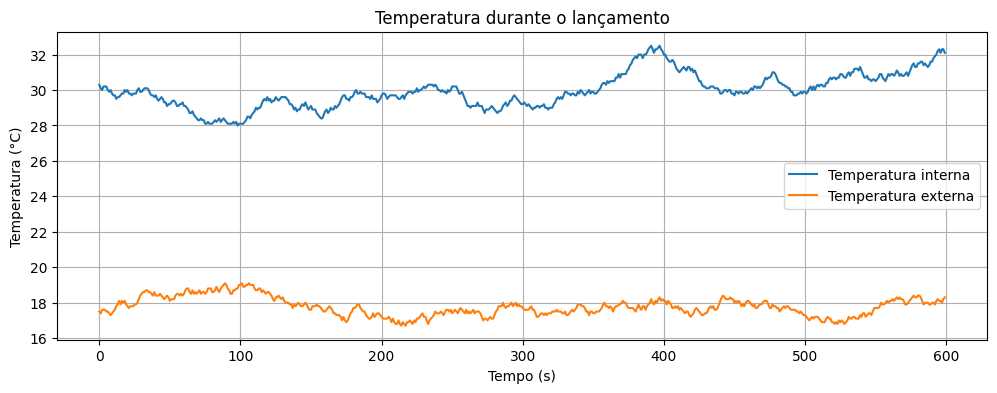

In [395]:
def exibir_grafico_temperatura(df):
  plt.figure(figsize=(12, 4))

  plt.plot(
      df["segundo"],
      df["temperatura_interna"],
      label="Temperatura interna"
  )

  plt.plot(
      df["segundo"],
      df["temperatura_externa"],
      label="Temperatura externa"
  )

  plt.xlabel("Tempo (s)")
  plt.ylabel("Temperatura (°C)")
  plt.title("Temperatura durante o lançamento")
  plt.legend()
  plt.grid()
  plt.show()

exibir_grafico_temperatura(df)

## Pressão

Será apresentado um gráfico da pressão do tanque em função do tempo.

A visualização permitirá identificar oscilações e possíveis alterações no comportamento da pressão.

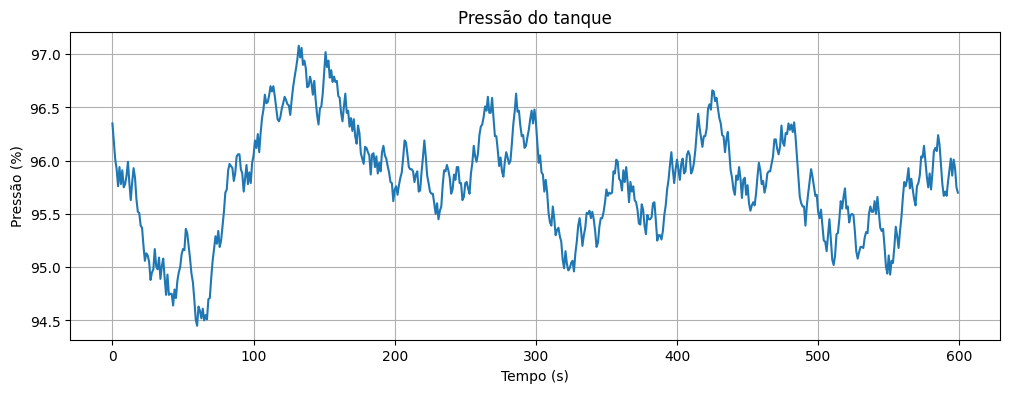

In [396]:
def exibir_grafico_pressao(df):
  plt.figure(figsize=(12, 4))

  plt.plot(
      df["segundo"],
      df["pressao"]
  )

  plt.xlabel("Tempo (s)")
  plt.ylabel("Pressão (%)")
  plt.title("Pressão do tanque")
  plt.grid()
  plt.show()

exibir_grafico_pressao(df)

## Potência e Bateria

A potência e a carga da bateria serão apresentadas no mesmo gráfico.

Essa combinação permite observar a relação entre a potência utilizada em cada etapa e a redução acumulada da bateria.

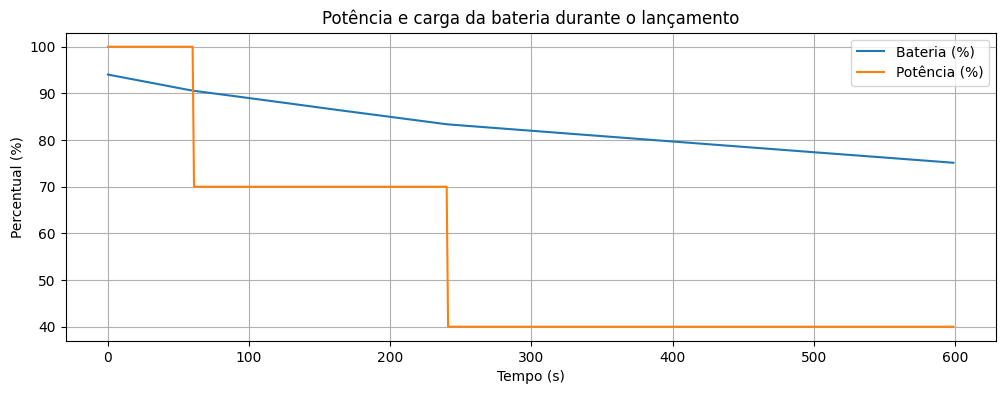

In [397]:
def exibir_grafico_bateria_potencia(df):
  plt.figure(figsize=(12, 4))

  plt.plot(
      df["segundo"],
      df["carga_da_bateria"],
      label="Bateria (%)"
  )

  plt.plot(
      df["segundo"],
      df["potencia"],
      label="Potência (%)"
  )

  plt.xlabel("Tempo (s)")
  plt.ylabel("Percentual (%)")
  plt.title("Potência e carga da bateria durante o lançamento")
  plt.legend()
  plt.grid()
  plt.show()

exibir_grafico_bateria_potencia(df)

# Análise dos resultados utilizando inteligência artificial

Após o término da simulação, o histórico completo da telemetria é enviado para uma inteligência artificial para uma análise final dos resultados.

Essa etapa possui uma função diferente das verificações realizadas anteriormente.

O programa utiliza regras determinísticas para decidir se o lançamento inicial pode ser autorizado. Já a inteligência artificial recebe o histórico completo da missão e analisa o comportamento dos dados durante os 600 segundos de simulação.

A IA recebe o DataFrame juntamente com o contexto necessário para interpretar os valores, incluindo:

- Limites seguros de temperatura;
- Limite mínimo de bateria;
- Faixa segura de pressão;
- Significado da integridade dos módulos;
- Comportamento esperado da potência;
- Comportamento esperado da bateria;
- Comportamento esperado das oscilações de temperatura e pressão;
- Relação entre potência e consumo energético.

---

## Comportamentos esperados

A análise precisa diferenciar comportamentos normais da simulação de possíveis anomalias.

A redução planejada da potência de 100% para 70% e posteriormente para 40% não é considerada uma anomalia.

A redução progressiva da bateria também é esperada, pois representa o consumo de energia durante a simulação.

Da mesma forma, pequenas oscilações de temperatura e pressão fazem parte do modelo e não devem ser classificadas como anomalias apenas por apresentarem variações.

O consumo energético também varia conforme a potência utilizada. Portanto, um consumo maior durante períodos de maior potência é um comportamento esperado.

---
## Identificação de anomalias

A IA deve procurar desvios em relação aos comportamentos definidos para a simulação, como:

- Temperatura fora da faixa segura;
- Pressão fora da faixa segura;
- Falha em algum módulo crítico;
- Oscilações anormalmente grandes;
- Mudanças abruptas não relacionadas às etapas planejadas;
- Consumo energético incompatível com a potência utilizada;
- Combinações de eventos que possam indicar uma situação de risco.

A IA não deve considerar um parâmetro anômalo simplesmente porque ele aumentou, diminuiu ou mudou de nível. É necessário considerar o contexto e os comportamentos definidos como esperados.

---

## Classificação

Com base nos dados da telemetria, a IA classifica o estado da simulação em uma das três categorias:

- RISCO BAIXO
- RISCO MÉDIO
- RISCO ALTO

A classificação deve considerar somente os problemas ou desvios relevantes identificados no histórico.

---

## Resposta estruturada

Para permitir que o resultado seja utilizado diretamente pelo programa, a IA não retorna uma resposta textual livre.

Ela retorna exclusivamente um objeto JSON contendo três informações:

classificacao: classificação geral da simulação;
anomalias: lista das possíveis anomalias identificadas;
sugestao: orientação relacionada aos resultados encontrados.

A estrutura utilizada é:

```json
{
    "classificacao": "RISCO BAIXO",
    "anomalias": [],
    "sugestao": "Os parâmetros permaneceram dentro das condições esperadas durante a simulação."
}
```
Quando forem identificadas anomalias, elas serão armazenadas individualmente na lista correspondente.

Essa estrutura permite que o Python interprete diretamente cada parte da resposta da IA, sem precisar analisar ou separar um texto livre.

Por fim, o JSON é utilizado pelo programa para gerar uma apresentação visual da análise final no Google Colab.

Dessa maneira, o fluxo completo do projeto é:

**Geração da telemetria → Verificação inicial → Simulação de 600 segundos → Organização dos dados → Visualização → Análise por IA → Apresentação do resultado final.**

A inteligência artificial, portanto, funciona como a etapa final de interpretação dos dados produzidos pela simulação, enquanto as etapas anteriores são responsáveis pela geração, processamento e organização dessas informações.

In [398]:
prompt = f"""
Você é um sistema de análise de telemetria responsável por avaliar os dados de uma simulação acadêmica do foguete AURORA.

Analise o DataFrame fornecido considerando os limites e comportamentos definidos para esta simulação.

## Limites de referência

* Temperatura interna: 15 °C a 35 °C
* Temperatura externa: 0 °C a 40 °C
* Pressão do tanque: 90% a 110%
* Integridade: OK quando todos os módulos estão funcionando e FALHA quando pelo menos um módulo apresenta falha.

## Comportamentos esperados

Alguns comportamentos observados no DataFrame são intencionais e fazem parte do funcionamento normal da simulação. Eles NÃO devem ser considerados anomalias.

### Potência

A potência é controlada de acordo com as etapas do lançamento:

* 100% durante a etapa inicial;
* 70% durante a etapa intermediária;
* 40% durante a etapa final.

Portanto, as reduções de potência de 100% para 70% e de 70% para 40% são comportamentos planejados e não representam falhas.

### Bateria

A carga da bateria deve diminuir progressivamente durante a simulação, pois o foguete está consumindo energia.

A redução da bateria, por si só, é um comportamento esperado e não deve ser classificada como anomalia.

A bateria só deve ser considerada um problema caso seja apresentado um comportamento de consumo significativamente diferente do esperado.

### Temperatura e pressão

Pequenas oscilações na temperatura e na pressão são esperadas devido ao comportamento simulado dos sensores.

Essas oscilações não devem ser classificadas como anomalias enquanto permanecerem dentro das respectivas faixas de segurança e não apresentarem uma alteração significativa ou inesperada de comportamento.

### Consumo energético

O consumo energético varia de acordo com a potência utilizada.

Portanto, períodos de maior consumo durante operações de maior potência são esperados.

As perdas energéticas também fazem parte do modelo da simulação e não devem ser consideradas uma anomalia.

## O que deve ser considerado uma anomalia

A análise deve procurar principalmente situações que representem um desvio do comportamento esperado, como:

* temperatura fora da faixa segura;
* pressão fora da faixa segura;
* falha em algum módulo crítico;
* oscilações anormalmente grandes;
* mudanças abruptas que não estejam relacionadas às etapas planejadas do lançamento;
* comportamento de consumo energético incompatível com a potência utilizada;
* combinações de eventos que indiquem uma possível situação de risco.

Não classifique como anomalia simplesmente o fato de um valor estar aumentando, diminuindo ou mudando de nível quando essa mudança é esperada pelo funcionamento da simulação.

Com base exclusivamente nos dados fornecidos, classifique o estado da simulação como:

* RISCO BAIXO
* RISCO MÉDIO
* RISCO ALTO

A classificação deve considerar somente problemas ou desvios relevantes encontrados nos dados.

Retorne exclusivamente um objeto JSON válido, sem markdown, sem explicações adicionais e sem bloco de código.

O JSON deve obrigatoriamente possuir esta estrutura:

{{
    "classificacao": "RISCO BAIXO | RISCO MÉDIO | RISCO ALTO",
    "anomalias": [
        "descrição da anomalia"
    ],
    "sugestao": "sugestão de ação"
}}

Se nenhuma anomalia relevante for identificada, retorne:

{{
    "classificacao": "RISCO BAIXO",
    "anomalias": [],
    "sugestao": "Os parâmetros permaneceram dentro das condições esperadas durante a simulação."
}}

Não invente informações que não estejam presentes no DataFrame.
Não altere os dados.
Não considere comportamentos explicitamente definidos como esperados uma anomalia.
Não faça afirmações sobre foguetes reais. A análise deve se limitar à simulação acadêmica apresentada.

Dados da telemetria:

{df.to_string(index=False)}
"""

In [399]:
import os
import json

from google.colab import userdata
from google import genai

os.environ["GOOGLE_API_KEY"] = userdata.get("GEMINI_API_KEY")

client = genai.Client()

resposta_ia = client.models.generate_content(model="gemini-3.1-flash-lite", contents=[prompt]).text

resultado = json.loads(resposta_ia)

In [400]:
from IPython.display import display, HTML

def exibir_resultado_lancamento():

  classificacao = resultado["classificacao"]
  anomalias = resultado["anomalias"]
  sugestao = resultado["sugestao"]

  if "ALTO" in classificacao:
      status_cor = "#dc2626"
      status_icone = "🔴"
  elif "MÉDIO" in classificacao:
      status_cor = "#d97706"
      status_icone = "🟠"
  else:
      status_cor = "#16a34a"
      status_icone = "🟢"

  anomalias_html = ""

  if anomalias:
      anomalias_html = "".join(
          f"<li>{anomalia}</li>"
          for anomalia in anomalias
      )
  else:
      anomalias_html = "<li>Nenhuma anomalia relevante identificada.</li>"

  html = f"""
  <div style="
      border: 1px solid #d1d5db;
      border-radius: 12px;
      padding: 24px;
      margin: 15px 0;
      font-family: Arial, sans-serif;
      background-color: #191919;
      box-shadow: 0 2px 8px rgba(0,0,0,0.08);
  ">

      <h2 style="margin-top: 0;">
          🚀 Análise da Missão AURORA
      </h2>

      <div style="
          background-color: {status_cor};
          color: white;
          padding: 14px;
          border-radius: 8px;
          font-size: 20px;
          font-weight: bold;
          text-align: center;
          margin: 15px 0;
      ">
          {status_icone} {classificacao}
      </div>

      <h3>⚠️ Possíveis anomalias</h3>

      <ul>
          {anomalias_html}
      </ul>

      <h3>💡 Sugestão</h3>

      <div style="
          border-left: 4px solid {status_cor};
          padding: 12px 16px;
          border-radius: 4px;
      ">
          {sugestao}
      </div>

  </div>
  """

  display(HTML(html))

exibir_resultado_lancamento()